# Static Dislocation Analytics

Time-shifted logit fit with **cross-sectional demeaning**: residuals
measure each node's deviation from the curve *relative to* the other
nodes, so parallel shifts produce zero signal.

1. Predicted vs actual (time-shifted)
2. Conditional ACF — autocorrelation of residual *changes* computed
   only at timestamps where the signal is active (`|resid| > threshold`).


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib

import curve_pipeline as _cp
importlib.reload(_cp)

from curve_pipeline import (
    build_deadline_market_universe,
    build_history_panel,
    score_time_shifted_dislocations,
    event_ids_poor_static_fit,
)

ImportError: cannot import name 'event_ids_poor_static_fit' from 'curve_pipeline' (/Users/AnranSeverac/YieldCurveModel/curve_pipeline.py)

In [ ]:
MAX_EVENTS = 1200
MAX_MARKETS = 400
LOOKBACK_DAYS = 90
INTERVAL = "1h"                      # hourly bars
FIDELITY = 0                         # 0 = use interval endpoint (coarser, longer history)
BAR_MINUTES = 60                       # for ACF display when FIDELITY=0 (hourly)

STATIC_LAG = 3                       # 3 bars = 3h lag
STATIC_MIN_NODES = 2
STATIC_POLY_DEGREE = 2
REF_SMOOTH_BARS = 3                  # smooth reference over 3 bars

SIGNAL_THRESHOLD = 0.15

EXCLUDE_EVENT_IDS = ["114242", "107011"]
EXCLUDE_POOR_FIT = True              # drop events with worst static-model fit
POOR_FIT_MIN_OBS = 50
POOR_FIT_EXCLUDE_WORST_PCT = 10.0    # exclude worst 10% of events by mean |residual|

# Conditional ACF
MAX_ACF_LAG = 60                     # bars; 60 * 1h = 60 hours
ACF_DISPLAY_LAGS = [1, 2, 3, 5, 10, 15, 20, 30, 45, 60]

## 1. Build universe & fetch data

In [ ]:
universe_df = build_deadline_market_universe(
    max_events=MAX_EVENTS, min_distinct_dates=2, include_closed=True,
)
print(f"Universe: {len(universe_df)} markets across {universe_df['event_id'].nunique()} events")

universe_df = universe_df[
    (pd.to_datetime(universe_df['deadline_date']) >= pd.Timestamp.now())
    & (~universe_df['event_id'].isin(EXCLUDE_EVENT_IDS))
]
print(f"After filtering: {len(universe_df)} markets across {universe_df['event_id'].nunique()} events")

panel_df = build_history_panel(
    universe_df, lookback_days=LOOKBACK_DAYS,
    interval=INTERVAL, fidelity=FIDELITY, max_markets=MAX_MARKETS,
)
print(f"Panel: {len(panel_df):,} rows, {panel_df['event_id'].nunique()} events")

Universe: 547 markets across 138 events
After filtering: 418 markets across 136 events


KeyboardInterrupt: 

## 2. Static signal (time-shifted, demeaned)

In [ ]:
static_df = score_time_shifted_dislocations(
    panel_df,
    lag_bars=STATIC_LAG,
    min_nodes=STATIC_MIN_NODES,
    poly_degree=STATIC_POLY_DEGREE,
    ref_smooth_bars=REF_SMOOTH_BARS,
)
static_df = static_df.dropna(subset=["ts_predicted_prob"])
if EXCLUDE_POOR_FIT:
    poor_fit_ids = event_ids_poor_static_fit(
        static_df,
        min_obs_per_event=POOR_FIT_MIN_OBS,
        exclude_worst_pct=POOR_FIT_EXCLUDE_WORST_PCT,
    )
    static_df = static_df[~static_df["event_id"].astype(str).isin(poor_fit_ids)]
    print(f"Excluded {len(poor_fit_ids)} events (poor static fit)")
print(f"Static signal rows: {len(static_df):,}")
print(f"Events: {static_df['event_id'].nunique()}")

Static signal rows: 454,432
Events with signal: 41


## 3. Predicted vs actual

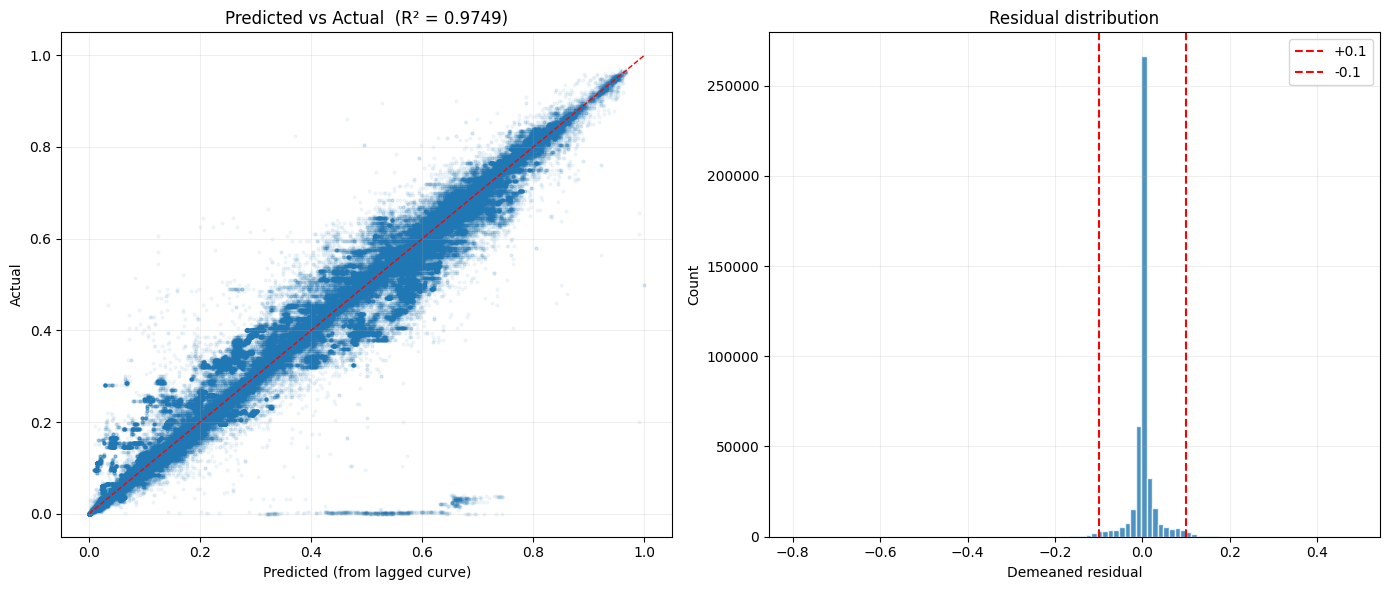

Observations with |resid| >= 0.1: 11,678 / 454,432 (2.57%)


In [ ]:
df = static_df.copy()
r2 = 1.0 - (df["ts_residual"] ** 2).sum() / ((df["probability_yes"] - df["probability_yes"].mean()) ** 2).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df["ts_predicted_prob"], df["probability_yes"], alpha=0.05, s=4)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[0].set_xlabel("Predicted (from lagged curve)")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Predicted vs Actual  (R² = {r2:.4f})")
axes[0].grid(True, alpha=0.2)

axes[1].hist(df["ts_residual"].dropna(), bins=100, edgecolor="white", alpha=0.8)
axes[1].axvline(SIGNAL_THRESHOLD, color="red", linestyle="--", label=f"+{SIGNAL_THRESHOLD}")
axes[1].axvline(-SIGNAL_THRESHOLD, color="red", linestyle="--", label=f"-{SIGNAL_THRESHOLD}")
axes[1].set_xlabel("Demeaned residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

n_above = (df["ts_residual"].abs() >= SIGNAL_THRESHOLD).sum()
print(f"Observations with |resid| >= {SIGNAL_THRESHOLD}: {n_above:,} / {len(df):,} ({n_above/len(df):.2%})")

## 4. Conditional ACF (split by sign)

Autocorrelation of residual *changes* (Δresid), split into two
panels:

- **Overpriced** (`resid > +threshold`): node is too expensive
  relative to curve — we would SELL.
- **Underpriced** (`resid < −threshold`): node is too cheap
  relative to curve — we would BUY.

Splitting prevents symmetric effects from cancelling each other.

Overpriced  nodes with enough data: 11  (total triggered obs: 5174)
Underpriced nodes with enough data: 8  (total triggered obs: 5560)


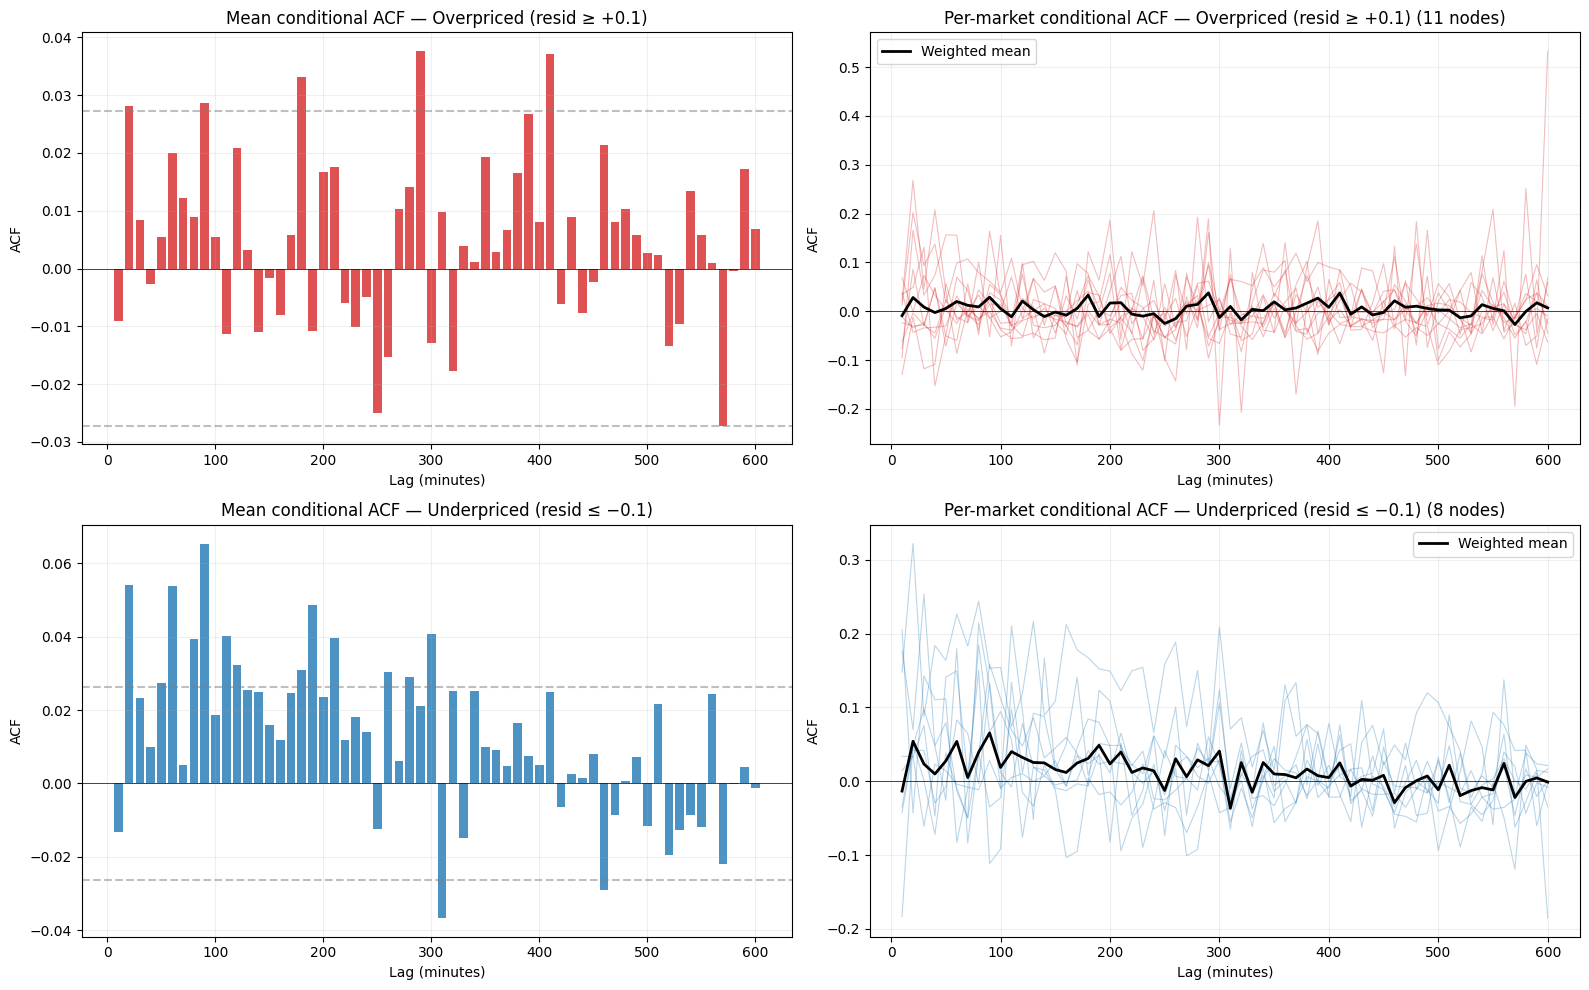


Overpriced (resid ≥ +0.1) — conditional ACF at key lags:
  lag   10m (=1 bars):  -0.0090
  lag   20m (=2 bars):  0.0281
  lag   30m (=3 bars):  0.0085
  lag   50m (=5 bars):  0.0055
  lag  100m (=10 bars):  0.0055
  lag  150m (=15 bars):  -0.0017
  lag  200m (=20 bars):  0.0167
  lag  300m (=30 bars):  -0.0129
  lag  450m (=45 bars):  -0.0024
  lag  600m (=60 bars):  0.0068

Underpriced (resid ≤ −0.1) — conditional ACF at key lags:
  lag   10m (=1 bars):  -0.0133
  lag   20m (=2 bars):  0.0541
  lag   30m (=3 bars):  0.0233
  lag   50m (=5 bars):  0.0275
  lag  100m (=10 bars):  0.0187
  lag  150m (=15 bars):  0.0159
  lag  200m (=20 bars):  0.0234
  lag  300m (=30 bars):  0.0408
  lag  450m (=45 bars):  0.0081
  lag  600m (=60 bars):  -0.0011


In [ ]:
def conditional_acf(series, condition_mask, max_lag):
    """ACF of `series` using only observations where condition_mask is True."""
    x = series.copy()
    x[~condition_mask] = np.nan
    x_valid = x.dropna()
    if len(x_valid) < max_lag + 10:
        return np.full(max_lag, np.nan)
    x_centered = x_valid - x_valid.mean()
    var = (x_centered ** 2).mean()
    if var < 1e-12:
        return np.full(max_lag, np.nan)
    acf = np.full(max_lag, np.nan)
    vals = x_centered.values
    for k in range(1, max_lag + 1):
        if len(vals) <= k:
            break
        acf[k - 1] = np.mean(vals[k:] * vals[:-k]) / var
    return acf


def _collect_acfs(df_acf, mask_col, max_lag):
    """Gather per-market conditional ACFs for a given boolean column."""
    acfs, weights = [], []
    for (eid, dd), grp in df_acf.groupby(["event_id", "deadline_date"]):
        ts = grp.sort_values("timestamp")
        shock = ts["idio_shock"]
        cond = ts[mask_col]
        if cond.sum() < max_lag + 10:
            continue
        acf_vals = conditional_acf(shock, cond, max_lag)
        if np.all(np.isfinite(acf_vals)):
            acfs.append(acf_vals)
            weights.append(int(cond.sum()))
    return acfs, weights


# ---------- Prepare data ----------
df_acf = static_df.sort_values(["event_id", "deadline_date", "timestamp"]).copy()
df_acf["d_resid"] = df_acf.groupby(["event_id", "deadline_date"])["ts_residual"].diff()

group_mean = df_acf.groupby(["event_id", "timestamp"])["d_resid"].transform("mean")
df_acf["idio_shock"] = df_acf["d_resid"] - group_mean

# Two separate condition masks
df_acf["overpriced"] = df_acf["ts_residual"] >= SIGNAL_THRESHOLD
df_acf["underpriced"] = df_acf["ts_residual"] <= -SIGNAL_THRESHOLD

# ---------- Collect ACFs ----------
acfs_over, w_over = _collect_acfs(df_acf, "overpriced", MAX_ACF_LAG)
acfs_under, w_under = _collect_acfs(df_acf, "underpriced", MAX_ACF_LAG)

print(f"Overpriced  nodes with enough data: {len(acfs_over)}  "
      f"(total triggered obs: {sum(w_over) if w_over else 0})")
print(f"Underpriced nodes with enough data: {len(acfs_under)}  "
      f"(total triggered obs: {sum(w_under) if w_under else 0})")

# ---------- Plot ----------
lags = np.arange(1, MAX_ACF_LAG + 1)
lag_minutes = lags * (BAR_MINUTES if FIDELITY == 0 else FIDELITY)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

panels = [
    (acfs_over, w_over, f"Overpriced (resid ≥ +{SIGNAL_THRESHOLD})", "tab:red"),
    (acfs_under, w_under, f"Underpriced (resid ≤ −{SIGNAL_THRESHOLD})", "tab:blue"),
]

for row, (acf_list, wt_list, label, color) in enumerate(panels):
    if not acf_list:
        for c in range(2):
            axes[row, c].set_title(f"{label} — insufficient data")
        continue

    acf_matrix = np.array(acf_list)
    wts = np.array(wt_list, dtype=float)
    wts /= wts.sum()
    mean_acf = (acf_matrix * wts[:, None]).sum(axis=0)
    n_eff = sum(wt_list)
    ci = 1.96 / np.sqrt(n_eff)

    # Left: mean ACF bar chart
    axes[row, 0].bar(lag_minutes, mean_acf, width=(BAR_MINUTES if FIDELITY == 0 else FIDELITY) * 0.8,
                     alpha=0.8, color=color)
    axes[row, 0].axhline(0, color="black", linewidth=0.5)
    axes[row, 0].axhline(ci, color="grey", linestyle="--", alpha=0.5)
    axes[row, 0].axhline(-ci, color="grey", linestyle="--", alpha=0.5)
    axes[row, 0].set_xlabel("Lag (minutes)")
    axes[row, 0].set_ylabel("ACF")
    axes[row, 0].set_title(f"Mean conditional ACF — {label}")
    axes[row, 0].grid(True, alpha=0.2)

    # Right: per-market ACF lines
    for acf_row in acf_matrix:
        axes[row, 1].plot(lag_minutes, acf_row, alpha=0.3, linewidth=0.8,
                          color=color)
    axes[row, 1].plot(lag_minutes, mean_acf, color="black", linewidth=2,
                      label="Weighted mean")
    axes[row, 1].axhline(0, color="black", linewidth=0.5)
    axes[row, 1].set_xlabel("Lag (minutes)")
    axes[row, 1].set_ylabel("ACF")
    axes[row, 1].set_title(f"Per-market conditional ACF — {label} "
                           f"({len(acf_list)} nodes)")
    axes[row, 1].legend()
    axes[row, 1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# ---------- Key lags ----------
for acf_list, wt_list, label, _ in panels:
    if not acf_list:
        continue
    acf_matrix = np.array(acf_list)
    wts = np.array(wt_list, dtype=float)
    wts /= wts.sum()
    mean_acf = (acf_matrix * wts[:, None]).sum(axis=0)
    print(f"\n{label} — conditional ACF at key lags:")
    for k in ACF_DISPLAY_LAGS:
        if k <= MAX_ACF_LAG:
            print(f"  lag {k * (BAR_MINUTES if FIDELITY == 0 else FIDELITY):4d}m (={k} bars):  {mean_acf[k-1]:.4f}")